# DG4000 信号发生器编程控制示例

本示例演示如何使用 `signal_generator` 包控制 RIGOL DG4000 系列函数/任意波形发生器。

## 前提条件
- 信号发生器已通过 USB/LAN 连接
- VISA 驱动已安装 (NI-VISA 或 RIGOL VISA)
- 虚拟环境 `agent_exp_env` 已配置好依赖
- 在 VSCode 中打开此 notebook 后，右上角选择内核 `Python (agent_exp_env)`

In [52]:
from signal_generator import DG4000Instrument, SignalGeneratorConfig, MultiGeneratorSetup
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

print("模块导入成功")

模块导入成功


---
## 1. 连接仪器

首先需要确定仪器的 VISA 资源字符串。可以使用 `pyvisa` 列出可用资源：

In [53]:
import pyvisa
rm = pyvisa.ResourceManager()
resources = rm.list_resources()
print("可用 VISA 资源:")
for i, res in enumerate(resources):
    print(f"  [{i}] {res}")
rm.close()

可用 VISA 资源:
  [0] USB0::0x1AB1::0x0641::DG4E231500376::INSTR
  [1] USB0::0x1AB1::0x0646::DG9Q271200104::INSTR
  [2] USB0::0x1AB1::0x0641::DG4E222800868::INSTR
  [3] USB0::0x1AB1::0x0641::DG4E234902522::INSTR
  [4] USB0::0x0B21::0x0039::90Z631552::INSTR
  [5] USB0::0x1AB1::0x0641::DG4E242401288::INSTR
  [6] USB0::0xF4EC::0x1015::SDSEV82X900704::INSTR
  [7] ASRL1::INSTR
  [8] ASRL3::INSTR


In [54]:
# 根据上一步结果，修改为实际的资源字符串
RESOURCE = "USB0::0x1AB1::0x0641::DG4E242401288::INSTR"

# 创建一个默认配置实例，后续单元格可直接使用
cfg = SignalGeneratorConfig(resource=RESOURCE, channel=1, label="信号源1",
                            shape="SINusoid", frequency=1000.0, amplitude=5.0)

# 使用上下文管理器连接（自动处理连接/断开）
try:
    with DG4000Instrument(RESOURCE) as dg:
        idn = dg.idn()
        print(f"已连接: {idn}")
        ver = dg.system_version()
        print(f"SCPI 版本: {ver}")
except Exception as e:
    print(f"连接失败: {e}")
    print("请检查资源字符串和仪器连接。以下示例将在模拟模式下展示。")

已连接: Rigol Technologies,DG4162,DG4E242401288,00.01.14
SCPI 版本: 1999.0


In [47]:
# 通道绑定示例: 为每个通道创建独立实例

ch1 = DG4000Instrument(RESOURCE, channel=1)
ch2 = DG4000Instrument(RESOURCE, channel=2)

with ch1, ch2:
    ch1.setup_sine(1000, 2.0, 1, 50)       # 自动用 CH1
    ch2.setup_square(100, 3.0, 2, 30, 50)      # 自动用 CH2
    print(f"CH1: {ch1.get_shape()}, {ch1.get_frequency():.0f} Hz")
    print(f"CH2: {ch2.get_shape()}, {ch2.get_frequency():.0f} Hz")
print("通道绑定模式: DG4000Instrument(RESOURCE, channel=n)")

CH1: SIN, 1000 Hz
CH2: SQU, 100 Hz
通道绑定模式: DG4000Instrument(RESOURCE, channel=n)


In [48]:
with ch1:
    ch1.set_shape("SINusoid")
    ch1.set_frequency(5000)       # 5 kHz
    ch1.set_amplitude(2.5)         # 2.5 Vpp
    ch1.set_offset(0.5)           # 0.5 V DC 偏置
    ch1.set_phase_adjust(45)      # 45° 初始相位
    ch1.set_output(True)

    print(f'CH1: {ch1.get_shape()}, {ch1.get_frequency():.0f} Hz, {ch1.get_amplitude():.2f} Vpp, {ch1.get_offset():.2f} V, {ch1.get_phase_adjust():.0f}°')

CH1: SIN, 5000 Hz, 2.50 Vpp, 0.50 V, 45°


## 通道绑定模式

每个 `DG4000Instrument` 实例可绑定到固定通道，后续调用无需再传 `channel=`：

```python
# 创建两个实例，分别绑定 CH1 和 CH2
ch1 = DG4000Instrument(RESOURCE, channel=1)
ch2 = DG4000Instrument(RESOURCE, channel=2)

ch1.set_frequency(1000)    # 操作 CH1
ch2.set_frequency(2000)    # 操作 CH2
```

也仍然支持在单个调用中临时指定其他通道。

---
## 2. 输出标准波形

### 2.1 正弦波

In [6]:
# 以下代码需要连接硬件才能运行。取消注释连接硬件后执行。
with DG4000Instrument(RESOURCE) as dg:
    # 一键配置正弦波: 1 kHz, 2 Vpp, 0 V 偏置
    dg.setup_sine(freq=1000, amplitude=2.0, offset=0.0, channel=1)
    print(f"CH1 已输出正弦波:")
    print(f"  频率: {dg.get_frequency(1):.2f} Hz")
    print(f"  幅度: {dg.get_amplitude(1):.4f} Vpp")
    print(f"  偏置: {dg.get_offset(1):.4f} V")
    print(f"  波形: {dg.get_shape(1)}")
print("(取消上方注释以连接真实硬件)")

CH1 已输出正弦波:
  频率: 1000.00 Hz
  幅度: 2.0000 Vpp
  偏置: 0.0000 V
  波形: SIN
(取消上方注释以连接真实硬件)


### 2.2 方波

In [7]:
with DG4000Instrument(RESOURCE) as dg:
    # 一键配置方波: 100 Hz, 3 Vpp, 30% 占空比
    dg.setup_square(freq=100, amplitude=3.0, offset=0.0,
                    dcycle=30.0, channel=1)
    print(f"CH1 已输出方波 (占空比 30%)")
print("(取消注释以连接真实硬件)")

CH1 已输出方波 (占空比 30%)
(取消注释以连接真实硬件)


### 2.3 斜波

In [8]:
with DG4000Instrument(RESOURCE) as dg:
    # 一键配置对称斜波: 10 Hz, 4 Vpp
    dg.setup_ramp(freq=10, amplitude=4.0, symmetry=50.0, channel=1)
    print(f"CH1 已输出斜波")
print("(取消注释以连接真实硬件)")

CH1 已输出斜波
(取消注释以连接真实硬件)


### 2.4 脉冲波

In [9]:
with DG4000Instrument(RESOURCE) as dg:
    # 一键配置脉冲: 1 kHz, 3.3 Vpp, 10 µs 脉宽
    dg.setup_pulse(freq=1000, amplitude=3.3, offset=0.0,
                   width=10e-6, channel=1)
    print(f"CH1 已输出脉冲波 (脉宽 10 µs)")
print("(取消注释以连接真实硬件)")

CH1 已输出脉冲波 (脉宽 10 µs)
(取消注释以连接真实硬件)


### 2.5 DC 电压和噪声

In [10]:
with DG4000Instrument(RESOURCE) as dg:
    # DC 输出: 1.5 V
    dg.setup_dc(voltage=1.5, channel=1)
    print("CH1 已输出 DC 1.5 V")

with DG4000Instrument(RESOURCE) as dg:
    # 噪声输出: 1 Vpp, 0 V 偏置
    dg.setup_noise(amplitude=1.0, offset=0.0, channel=1)
    print("CH1 已输出噪声")
print("(取消注释以连接真实硬件)")

CH1 已输出 DC 1.5 V
CH1 已输出噪声
(取消注释以连接真实硬件)


---
## 3. 手动配置波形参数

分步设置波形：选择波形类型、设置频率/幅度/偏置，然后打开输出。

In [11]:
with DG4000Instrument(RESOURCE) as dg:
    # 分步配置正弦波
    dg.set_shape("SINusoid", channel=1)
    dg.set_frequency(5000, channel=1)       # 5 kHz
    dg.set_amplitude(2.5, channel=1)         # 2.5 Vpp
    dg.set_offset(0.5, channel=1)           # 0.5 V DC 偏置
    dg.set_phase_adjust(45, channel=1)      # 45° 初始相位
    dg.set_output(True, channel=1)
    print(f"CH1: {dg.get_shape(1)}, {dg.get_frequency(1):.0f} Hz, "
          f"{dg.get_amplitude(1):.2f} Vpp, offset={dg.get_offset(1):.2f} V")
print("(取消注释以连接真实硬件)")

CH1: SIN, 5000 Hz, 2.50 Vpp, offset=0.50 V
(取消注释以连接真实硬件)


In [12]:
with ch1:
    # 分步配置正弦波
    ch1.set_shape("SINusoid")
    ch1.set_frequency(5000)       # 5 kHz
    ch1.set_amplitude(2.5)         # 2.5 Vpp
    ch1.set_offset(0.5)           # 0.5 V DC 偏置
    ch1.set_phase_adjust(45)      # 45° 初始相位
    ch1.set_output(True)
    print(f"CH1: {ch1.get_shape()}, {ch1.get_frequency():.0f} Hz, "
          f"{ch1.get_amplitude():.2f} Vpp, offset={ch1.get_offset():.2f} V")
print("(取消注释以连接真实硬件)")

CH1: SIN, 5000 Hz, 2.50 Vpp, offset=0.50 V
(取消注释以连接真实硬件)


### 幅度单位切换

In [13]:
# with DG4000Instrument(RESOURCE) as dg:
#     dg.set_voltage_unit("VRMS", channel=1)
#     print(f"幅度单位: {dg.get_voltage_unit(1)}")
#     dg.set_voltage_unit("VPP", channel=1)
#     print(f"幅度单位: {dg.get_voltage_unit(1)}")
print("(取消注释以连接真实硬件)")

(取消注释以连接真实硬件)


---
## 4. 输出控制

控制输出通道的开/关、负载阻抗和极性。

In [14]:
with DG4000Instrument(RESOURCE) as dg:
    dg.setup_sine(1000, 1.0, channel=1)
    print(f"CH1 输出: {dg.get_output(1)}")

    # 设置负载阻抗为 50 Ω
    dg.set_output_load('INFinity', channel=1)
    print(f"CH1 负载: {dg.get_output_load(1)}")

    # 关闭 CH1 输出
    dg.set_output(False, channel=1)
    print(f"CH1 输出: {dg.get_output(1)}")

    # 同时关闭所有通道
    dg.all_off()
print("(取消注释以连接真实硬件)")

CH1 输出: True
CH1 负载: INFINITY
CH1 输出: False
(取消注释以连接真实硬件)


---
## 5. 调制输出 (Modulation)

支持 AM、FM、PM、FSK、PWM 等多种调制方式。

In [15]:
with DG4000Instrument(RESOURCE) as dg:
    # 正弦波载波 (10 kHz)
    dg.setup_sine(10000, 2.0, channel=1)

    # 配置 AM 调制: 内部 100 Hz 正弦波调制, 深度 80%
    dg.set_mod_type("AM", channel=1)
    dg.set_mod_am_depth(80, channel=1)
    dg.set_mod_am_internal_freq(100, channel=1)
    dg.set_mod_am_internal_func("SINusoid", channel=1)
    dg.set_mod_state(True, channel=1)
    print(f"AM 调制已开启: 深度 80%, 调制频率 100 Hz")
    print(f"调制状态: {dg.get_mod_state(1)}")
print("(取消注释以连接真实硬件)")

AM 调制已开启: 深度 80%, 调制频率 100 Hz
调制状态: True
(取消注释以连接真实硬件)


In [16]:
with DG4000Instrument(RESOURCE) as dg:
    # 配置 FM 调制: 频偏 5 kHz, 内部 10 Hz 正弦波
    dg.setup_sine(10000, 2.0, channel=1)
    dg.set_mod_type("FM", channel=1)
    dg.set_mod_fm_deviation(5000, channel=1)
    dg.set_mod_fm_internal_freq(10, channel=1)
    dg.set_mod_fm_internal_func("SINusoid", channel=1)
    dg.set_mod_state(True, channel=1)
    print(f"FM 调制已开启: 频偏 5 kHz, 调制频率 10 Hz")
print("(取消注释以连接真实硬件)")

FM 调制已开启: 频偏 5 kHz, 调制频率 10 Hz
(取消注释以连接真实硬件)


---
## 6. 扫描输出 (Sweep)

在指定频率范围内扫描输出。

In [17]:
with DG4000Instrument(RESOURCE) as dg:
    # 方波载波, 频率在 100 Hz - 10 kHz 间线性扫描
    dg.setup_square(1000, 2.0, channel=1)

    dg.set_sweep_start_freq(100, channel=1)
    dg.set_sweep_stop_freq(10000, channel=1)
    dg.set_sweep_time(2.0, channel=1)         # 扫描周期 2 秒
    dg.set_sweep_spacing("LINear", channel=1)  # 线性扫描
    dg.set_sweep_state(True, channel=1)
    print("扫描输出已开启 (100 Hz → 10 kHz, 线性, 2 s)")
print("(取消注释以连接真实硬件)")

扫描输出已开启 (100 Hz → 10 kHz, 线性, 2 s)
(取消注释以连接真实硬件)


---
## 7. 脉冲串输出 (Burst)

输出指定数量的波形周期。

In [18]:
with DG4000Instrument(RESOURCE) as dg:
    # 正弦波, 5 个周期脉冲串
    dg.setup_sine(1000, 2.0, channel=1)
    dg.set_burst_mode("TRIGgered", channel=1)
    dg.set_burst_ncycles(5, channel=1)
    dg.set_burst_phase(0, channel=1)
    dg.set_burst_period(0.1, channel=1)       # 脉冲串周期 100 ms
    dg.set_burst_state(True, channel=1)
    print("脉冲串模式已开启: 5 cycles, 100 ms 周期")
print("(取消注释以连接真实硬件)")

脉冲串模式已开启: 5 cycles, 100 ms 周期
(取消注释以连接真实硬件)


---
## 8. 双通道操作

DG4000 支持两个独立通道。

In [19]:
# with DG4000Instrument(RESOURCE) as dg:
#     # CH1: 1 kHz 正弦波
#     dg.setup_sine(1000, 2.0, offset=0.0, channel=1)
#
#     # CH2: 100 Hz 方波
#     dg.setup_square(100, 3.0, offset=0.5, dcycle=50, channel=2)
#     print(f"CH1: {dg.get_shape(1)}, {dg.get_frequency(1):.0f} Hz")
#     print(f"CH2: {dg.get_shape(2)}, {dg.get_frequency(2):.0f} Hz")
print("(取消注释以连接真实硬件)")

(取消注释以连接真实硬件)


---
## 9. 谐波输出

In [20]:
# with DG4000Instrument(RESOURCE) as dg:
#     dg.setup_sine(1000, 2.0, channel=1)
#     dg.set_harmonic_type("EVEN", channel=1)
#     dg.set_harmonic_order(2, channel=1)
#     dg.set_harmonic_amplitude(0.5, channel=1)
#     print("谐波输出已配置: 偶次, 2 阶, 0.5 V")
print("(取消注释以连接真实硬件)")

(取消注释以连接真实硬件)


---
## 10. 系统命令

In [21]:
# with DG4000Instrument(RESOURCE) as dg:
#     # 查询错误
#     err = dg.system_error()
#     print(f"系统错误: {err}")
#
#     # 蜂鸣
#     dg.system_beep()
#
#     # 复位
#     dg.reset()
#     print("仪器已复位")
print("(取消注释以连接真实硬件)")

(取消注释以连接真实硬件)


---
## 11. 状态保存与恢复

In [22]:
# with DG4000Instrument(RESOURCE) as dg:
#     # 保存当前状态到存储位置 0
#     dg.save_state(0)
#     print("状态已保存到位置 0")
#
#     # 恢复状态
#     dg.recall_state(0)
#     print("状态已恢复")
print("(取消注释以连接真实硬件)")

(取消注释以连接真实硬件)


---
## 12. APPLy 底层命令

`apply_wave()` 是对 SCPI `:APPLy:<shape>` 命令的封装，可直接传递频率、幅度、偏置和相位。

In [23]:
# with DG4000Instrument(RESOURCE) as dg:
#     # 使用 apply_wave 直接设置 (频率, 幅度, 偏置, 相位)
#     dg.apply_wave("SINusoid", channel=1,
#                   freq=2000, amp=3.0, offset=0.2, phase=90)
#     dg.set_output(True, channel=1)
#
#     # 查询 APPLy 设置
#     print(f"CH1 APPLy: {dg.query_apply(1)}")
print("(取消注释以连接真实硬件)")

(取消注释以连接真实硬件)


---
## 13. 可用波形列表 (FUNCtion:SHAPe)

DG4000 支持的内置波形包括:

| 类型 | 名称 | 描述 |
|---|---|---|
| 基本 | SINusoid / SQUare / RAMP / PULSe / NOISe | 标准波形 |
| 特殊 | DC / PRBS / IQ | 直流 / 伪随机 / IQ 信号 |
| 谐波 | HARMonic | 谐波输出 |
| 任意 | USER | 用户自定义波形 (通过 TRACe 发送) |
| 内置 | >150 种内置函数 | Sinc, Gauss, Lorentz, 医疗波形 (ECG/EEG/EMG) 等 |

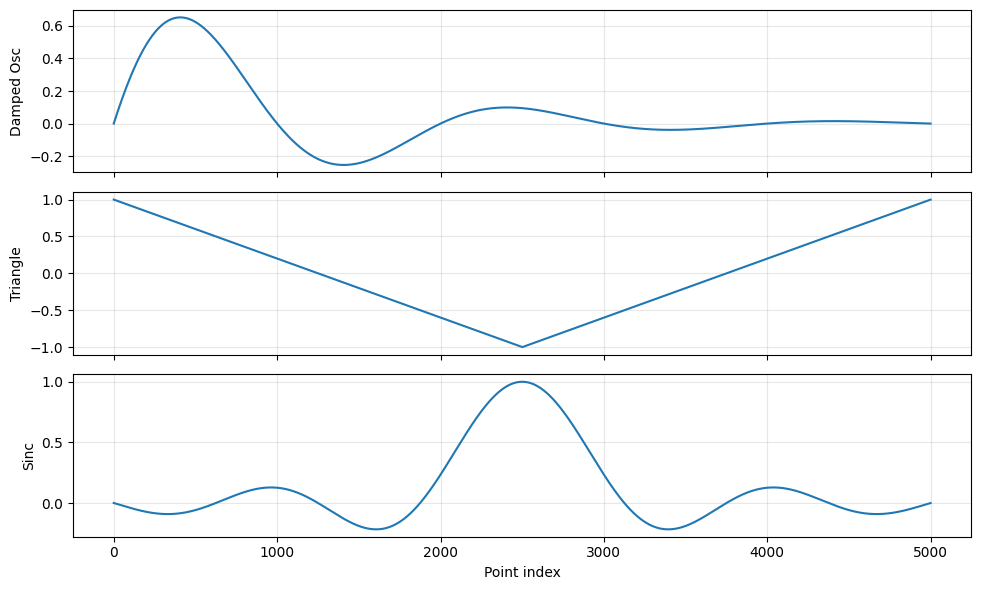

In [25]:
# 更多自定义波形示例
N = 5000  # 点数 (不超过 16384)

# 阻尼振荡
t = np.linspace(0, 5*np.pi, N, endpoint=False)
y_damped = np.exp(-0.3*t) * np.sin(t)

# 三角波 (分段线性)
t2 = np.linspace(0, 1, N, endpoint=False)
y_tri = 2 * np.abs(2*t2 - 1) - 1  # [-1, 1] 三角波

# Sinc 脉冲
t3 = np.linspace(-4*np.pi, 4*np.pi, N, endpoint=False)
y_sinc = np.sinc(t3/np.pi)  # numpy.sinc 已经是归一化的

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(y_damped); axes[0].set_ylabel("Damped Osc"); axes[0].grid(True, alpha=0.3)
axes[1].plot(y_tri); axes[1].set_ylabel("Triangle"); axes[1].grid(True, alpha=0.3)
axes[2].plot(y_sinc); axes[2].set_ylabel("Sinc"); axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel("Point index")
plt.tight_layout(); plt.show()

# 发送任意一种:
dg.setup_arbitrary(y_tri, freq=30, amplitude=4.0, channel=1)
dg.setup_arbitrary(y_damped, freq=30, amplitude=4.0, channel=2)

In [27]:
# 分步操作: 发送波形 → 配置参数 → 打开输出
with DG4000Instrument(RESOURCE, channel=1) as dg:
    # 1. 发送自定义波形数据
    dg.send_arbitrary_waveform(y_damped, channel=1)

    # 2. 配置输出参数 (USER 波形, 频率 100 Hz, 幅度 3 Vpp)
    dg.apply_wave("USER", channel=1, freq=100, amp=3.0, offset=0.5)

    # 3. 打开输出
    dg.set_output(True, channel=1)
    print("自定义波形已分步配置完成")
print("(取消注释以连接真实硬件)")

自定义波形已分步配置完成
(取消注释以连接真实硬件)


In [28]:
# 发送自定义波形到信号发生器并输出
with DG4000Instrument(RESOURCE, channel=1) as dg:
    # 方式一: 一步完成 (发送 + 配置 + 输出)
    dg.setup_arbitrary(y_damped, freq=50, amplitude=5.0, offset=0.0)
    print(f"自定义波形已输出: {dg.get_shape(1)}, {dg.get_frequency(1):.0f} Hz")
print("(取消注释以连接真实硬件)")

自定义波形已输出: USER, 50 Hz
(取消注释以连接真实硬件)


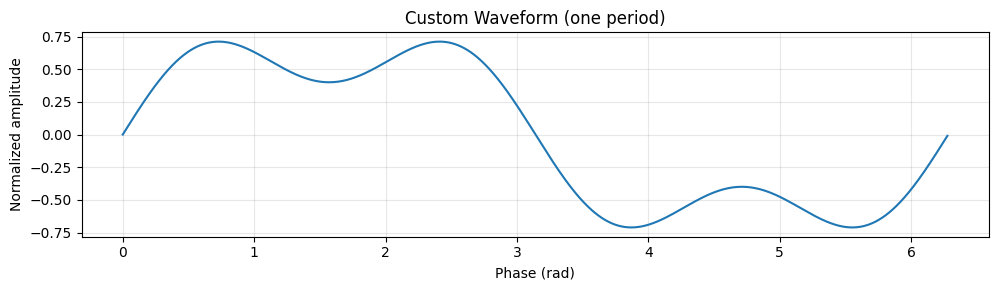

In [29]:
# 自定义波形: 正弦 + 三次谐波叠加
import numpy as np

# 在一个周期内生成 1000 个点
t = np.linspace(0, 2*np.pi, 1000, endpoint=False)
y = 0.7 * np.sin(t) + 0.3 * np.sin(3*t)  # 基波 + 3 次谐波
# y 的范围已经在 [-1, 1] 内

# 绘制查看
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, y)
ax.set_xlabel("Phase (rad)"); ax.set_ylabel("Normalized amplitude")
ax.set_title("Custom Waveform (one period)")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 15. 任意波 (Arbitrary Waveform)

可以发送自定义周期函数作为输出波形。数据点归一化到 [-1, +1] 范围。

In [ ]:
# 使用 set_shape 切换到任意内置波形
# with DG4000Instrument(RESOURCE) as dg:
#     dg.setup_sine(1000, 2.0, channel=1)
#
#     # 切换到 Sinc 脉冲
#     dg.set_shape("SINC", channel=1)
#     print(f"CH1 波形: {dg.get_shape(1)}")
print("(取消注释以连接真实硬件)")

In [31]:
with DG4000Instrument(RESOURCE) as dg:
    # 查询当前时钟源
    src = dg.get_ref_clock_source()
    print(f"当前参考时钟源: {src}")

    # 切换到外部参考时钟
    dg.set_ref_clock_source("EXTernal")
    print(f"已切换到: {dg.get_ref_clock_source()}")

    # 恢复为内部时钟
    dg.set_ref_clock_source("INTernal")
    print(f"已恢复: {dg.get_ref_clock_source()}")
print("(取消注释以连接真实硬件)")

当前参考时钟源: INT
已切换到: EXT
已恢复: INT
(取消注释以连接真实硬件)


In [55]:
# ---- 单台仪器配置 (覆盖全局 cfg，填充更多参数) ----
cfg = SignalGeneratorConfig(
    resource=RESOURCE,
    channel=1,
    label="信号源1",
    shape="SINusoid",
    frequency=1000.0,
    amplitude=5.0,
    offset=0.0,
    output_enabled=True,
    load=50.0,
)

# 保存到 YAML
yaml_path = str(Path.cwd().parent / "params" / "my_sg_config.yaml")
cfg.to_yaml(yaml_path)
print(f"配置已保存: {yaml_path}")

# 从 YAML 加载
cfg_loaded = SignalGeneratorConfig.from_yaml(yaml_path)
print(f"已加载: [{cfg_loaded.label}] {cfg_loaded.resource} CH{cfg_loaded.channel}")
print(f"  {cfg_loaded.shape} @ {cfg_loaded.frequency} Hz, {cfg_loaded.amplitude} Vpp")

配置已保存: d:\Code\exp_agent\params\my_sg_config.yaml
已加载: [信号源1] USB0::0x1AB1::0x0641::DG4E242401288::INSTR CH1
  SINusoid @ 1000.0 Hz, 5.0 Vpp


In [56]:
# ---- 多台仪器配置 (从 YAML 加载) ----
setup = MultiGeneratorSetup.from_yaml(
    str(Path.cwd().parent / "params" / "default_sg_config.yaml"))
print(f"加载了 {len(setup.configs)} 台仪器配置:")
for c in setup.configs:
    print(f"  [{c.label}] {c.resource} CH{c.channel}: {c.shape} {c.frequency} Hz")

# 将配置应用到已连接的仪器
# setup.apply_all({inst.resource: inst for inst in [sg1, sg2]})

加载了 2 台仪器配置:
  [参考信号] USB0::0x1AB1::0x0641::DG4E242401288::INSTR CH1: SINusoid 1000.0 Hz
  [调制源] USB0::0x1AB1::0x0641::DG4X162000002::INSTR CH1: SINusoid 100.0 Hz


In [57]:
# ---- 应用配置到真实硬件 ----
with DG4000Instrument(RESOURCE, channel=1) as dg:
    cfg.apply_to(dg)
    print(f"已应用配置: {dg.get_shape()}, {dg.get_frequency():.0f} Hz")
print("(取消注释以连接真实硬件应用配置)")

已应用配置: SIN, 1000 Hz
(取消注释以连接真实硬件应用配置)


In [58]:
# ---- 多台仪器配置 (从 YAML 加载) ----
setup = MultiGeneratorSetup.from_yaml(
    str(Path.cwd().parent / "params" / "default_sg_config.yaml"))
print(f"加载了 {len(setup.configs)} 台仪器配置:")
for c in setup.configs:
    print(f"  [{c.label}] {c.resource} CH{c.channel}: {c.shape} {c.frequency} Hz")

# 将配置应用到已连接的仪器
# setup.apply_all({inst.resource: inst for inst in [sg1, sg2]})

加载了 2 台仪器配置:
  [参考信号] USB0::0x1AB1::0x0641::DG4E242401288::INSTR CH1: SINusoid 1000.0 Hz
  [调制源] USB0::0x1AB1::0x0641::DG4X162000002::INSTR CH1: SINusoid 100.0 Hz


In [ ]:
# 导入配置类
from signal_generator import SignalGeneratorConfig, MultiGeneratorSetup
from pathlib import Path

# ---- 单台仪器配置 ----
cfg = SignalGeneratorConfig(
    resource=RESOURCE,
    channel=1,
    label="信号源1",
    shape="SINusoid",
    frequency=1000.0,
    amplitude=5.0,
    offset=0.0,
    output_enabled=True,
    load=50.0,
)

# 保存到 YAML
yaml_path = str(Path.cwd().parent / "params" / "my_sg_config.yaml")
cfg.to_yaml(yaml_path)
print(f"配置已保存: {yaml_path}")

# 从 YAML 加载
cfg_loaded = SignalGeneratorConfig.from_yaml(yaml_path)
print(f"已加载: [{cfg_loaded.label}] {cfg_loaded.resource} CH{cfg_loaded.channel}")
print(f"  {cfg_loaded.shape} @ {cfg_loaded.frequency} Hz, {cfg_loaded.amplitude} Vpp")

配置已保存: d:\Code\exp_agent\params\my_sg_config.yaml
已加载: [信号源1] USB0::0x1AB1::0x0641::DG4E242401288::INSTR CH1
  SINusoid @ 1000.0 Hz, 5.0 Vpp


: 

---
## 14. 快速提示

- **先配置后输出**: `set_output(True, ...)` 前完成所有参数设置，避免输出不期望的信号
- **负载阻抗**: 默认 50 Ω，如连接高阻负载需设置 `set_output_load("INF", ...)`，否则幅度不准确
- **调制互斥**: 调制、扫描、脉冲串三种模式互斥，开启一项会自动关闭其他
- **安全关机**: 实验结束时调用 `all_off()` 关闭所有通道
- **查询错误**: 命令执行失败后可调用 `system_error()` 查看错误信息